In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_customers_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_sellers_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_order_reviews_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_order_items_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_products_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_geolocation_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/product_category_name_translation.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_orders_dataset.csv
/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/olist_order_payments_dataset.csv


In [50]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, silhouette_score

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [51]:
# Load all datasets
DATA_PATH = "/kaggle/input/datasets/siddhart2004/olist-dataset-for-bdm/"

# Load individual datasets
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

# Display dataset shapes
datasets = {
    'Orders': orders,
    'Order Items': order_items,
    'Payments': payments,
    'Reviews': reviews,
    'Customers': customers,
    'Products': products,
    'Sellers': sellers,
    'Category Translation': category_translation
}

print("Dataset Overview:")
print("-" * 50)
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("-" * 50)

Dataset Overview:
--------------------------------------------------
Orders: 99,441 rows × 8 columns
Order Items: 112,650 rows × 7 columns
Payments: 103,886 rows × 5 columns
Reviews: 99,224 rows × 7 columns
Customers: 99,441 rows × 5 columns
Products: 32,951 rows × 9 columns
Sellers: 3,095 rows × 4 columns
Category Translation: 71 rows × 2 columns
--------------------------------------------------


In [52]:
# Check missing values in all datasets
def check_missing_values(datasets_dict):
    missing_summary = []
    
    for name, df in datasets_dict.items():
        total_missing = df.isnull().sum().sum()
        total_cells = df.shape[0] * df.shape[1]
        missing_pct = (total_missing / total_cells) * 100
        missing_summary.append({
            'Dataset': name,
            'Total Rows': df.shape[0],
            'Total Columns': df.shape[1],
            'Missing Values': total_missing,
            'Missing %': f"{missing_pct:.2f}%"
        })
    
    return pd.DataFrame(missing_summary)

print("Missing Values Summary:")
missing_df = check_missing_values(datasets)
print(missing_df.to_string(index=False))
print()

# Detailed missing values for Orders dataset
print("\n Detailed Missing Values - Orders Dataset:")
orders_missing = orders.isnull().sum()
orders_missing = orders_missing[orders_missing > 0]
if len(orders_missing) > 0:
    for col, count in orders_missing.items():
        print(f"  . {col}: {count:,} missing ({count/len(orders)*100:.2f}%)")
else:
    print("  No missing values found!")

Missing Values Summary:
             Dataset  Total Rows  Total Columns  Missing Values Missing %
              Orders       99441              8            4908     0.62%
         Order Items      112650              7               0     0.00%
            Payments      103886              5               0     0.00%
             Reviews       99224              7          145903    21.01%
           Customers       99441              5               0     0.00%
            Products       32951              9            2448     0.83%
             Sellers        3095              4               0     0.00%
Category Translation          71              2               0     0.00%


 Detailed Missing Values - Orders Dataset:
  . order_approved_at: 160 missing (0.16%)
  . order_delivered_carrier_date: 1,783 missing (1.79%)
  . order_delivered_customer_date: 2,965 missing (2.98%)


In [53]:
# Convert timestamp columns to datetime
timestamp_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
    
# Verifying the conversion
print("Timestamp Columns - Data Types After Conversion:")
print("-" * 50)
for col in timestamp_columns:
    print(f"  . {col}: {orders[col].dtype}")

Timestamp Columns - Data Types After Conversion:
--------------------------------------------------
  . order_purchase_timestamp: datetime64[ns]
  . order_approved_at: datetime64[ns]
  . order_delivered_carrier_date: datetime64[ns]
  . order_delivered_customer_date: datetime64[ns]
  . order_estimated_delivery_date: datetime64[ns]


In [54]:
# Merge products with category translations
products_merged = products.merge(category_translation, on='product_category_name', how='left')

# Create master dataframe by merging all datasets
# Step 1: Merge orders with order_items
df = orders.merge(order_items, on='order_id', how='inner')

# Step 2: Merge with products (including translated categories)
df = df.merge(products_merged, on='product_id', how='left')

# Step 3: Merge with customers
df = df.merge(customers, on='customer_id', how='left')

# Step 4: Merge with sellers
df = df.merge(sellers, on='seller_id', how='left')

# Step 5: Merge with payments (aggregated by order)
payments_agg = payments.groupby('order_id').agg({
    'payment_type': 'first',  # Primary payment type
    'payment_installments': 'max',
    'payment_value': 'sum'
}).reset_index()

df = df.merge(payments_agg, on='order_id', how='left')

# Step 6: Merge with reviews
reviews_clean = reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')
df = df.merge(reviews_clean, on='order_id', how='left')

print(f" Master DataFrame Created: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Columns in Master DataFrame:")
print(df.columns.tolist())

 Master DataFrame Created: 112,650 rows × 34 columns

 Columns in Master DataFrame:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_type', 'payment_installments', 'payment_value', 'review_score']


In [55]:
# Create derived features

# Temporal features from purchase timestamp
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day'] = df['order_purchase_timestamp'].dt.day
df['purchase_weekday'] = df['order_purchase_timestamp'].dt.day_name()
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

# Delivery time calculation (days from purchase to delivery)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Total order value (price + freight)
df['total_order_value'] = df['price'] + df['freight_value']

# Delivery delay (actual vs estimated)
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

print("New Features Created:")
new_features = ['purchase_year', 'purchase_month', 'purchase_day', 'purchase_weekday', 
                'purchase_hour', 'delivery_days', 'total_order_value', 'delivery_delay']
for feat in new_features:
    print(f"  . {feat}")

New Features Created:
  . purchase_year
  . purchase_month
  . purchase_day
  . purchase_weekday
  . purchase_hour
  . delivery_days
  . total_order_value
  . delivery_delay


In [56]:
# Check missing values before cleaning
print(" Missing Values Before Cleaning:")
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print(missing_before)

# Store original row count
original_rows = len(df)

# Remove rows where delivery date is missing
df_clean = df[df['order_delivered_customer_date'].notna()].copy()

# Remove rows with missing category names
df_clean = df_clean[df_clean['product_category_name_english'].notna()]

# Remove rows with missing review scores
df_clean = df_clean[df_clean['review_score'].notna()]

# Remove zero or negative values
df_clean = df_clean[df_clean['price'] > 0]
df_clean = df_clean[df_clean['freight_value'] > 0]

# Handle outliers in delivery_days (remove extreme values > 100 days)
df_clean = df_clean[(df_clean['delivery_days'] > 0) & (df_clean['delivery_days'] <= 100)]

# Final row count
final_rows = len(df_clean)

print(f"\n Data Cleaning Complete:")
print(f"  . Original rows: {original_rows:,}")
print(f"  . Final rows: {final_rows:,}")
print(f"  . Rows removed: {original_rows - final_rows:,} ({(original_rows - final_rows)/original_rows*100:.2f}%)")

# Verify no missing values in critical columns
print(f"\n Missing Values After Cleaning:")
missing_after = df_clean[['price', 'freight_value', 'delivery_days', 'review_score', 'payment_type']].isnull().sum()
print(missing_after)

 Missing Values Before Cleaning:
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1627
payment_type                        3
payment_installments                3
payment_value                       3
review_score                      942
delivery_days                    2454
delivery_delay                   2454
dtype: int64

 Data Cleaning Complete:
  . Original rows: 112,650
  . Final rows: 107,364
  . Rows removed: 5,286 (4.69%)

 Missing Values After Cleaning:
price            0
freight_value    0
delivery_days    0
review_score     0
payment_type     3
dtype: int64


In [57]:
# Key Variables Summary Table
key_variables = pd.DataFrame({
    'Variable': [
        'price',
        'freight_value',
        'total_order_value',
        'delivery_days',
        'review_score',
        'payment_value',
        'payment_installments'
    ],
    'Description': [
        'Product price in BRL',
        'Freight/shipping cost in BRL',
        'Total order value (price + freight)',
        'Days from purchase to delivery',
        'Customer review rating (1-5)',
        'Total payment amount in BRL',
        'Number of payment installments'
    ],
    'Data Type': [
        'Float',
        'Float',
        'Float',
        'Integer',
        'Integer',
        'Float',
        'Integer'
    ],
    'Role in Analysis': [
        'Regression feature, EDA',
        'Target variable for Ridge Regression',
        'Customer segmentation feature',
        'EDA, Clustering feature',
        'Clustering feature',
        'EDA, Clustering feature',
        'EDA'
    ]
})

print("KEY VARIABLES SUMMARY TABLE")
print("=" * 93)
print(key_variables.to_string(index=False))
print("=" * 93)

KEY VARIABLES SUMMARY TABLE
            Variable                         Description Data Type                     Role in Analysis
               price                Product price in BRL     Float              Regression feature, EDA
       freight_value        Freight/shipping cost in BRL     Float Target variable for Ridge Regression
   total_order_value Total order value (price + freight)     Float        Customer segmentation feature
       delivery_days      Days from purchase to delivery   Integer              EDA, Clustering feature
        review_score        Customer review rating (1-5)   Integer                   Clustering feature
       payment_value         Total payment amount in BRL     Float              EDA, Clustering feature
payment_installments      Number of payment installments   Integer                                  EDA


In [58]:
# Descriptive Statistics for Numerical Variables
numerical_cols = ['price', 'freight_value', 'total_order_value', 'delivery_days', 
                  'review_score', 'payment_value']

# Create descriptive statistics table
desc_stats = df_clean[numerical_cols].describe().T
desc_stats = desc_stats.round(2)
desc_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', '50% (Median)', '75%', 'Max']

print("\nDESCRIPTIVE STATISTICS TABLE")
print("=" * 93)
print(desc_stats.to_string())
print("=" * 93)


DESCRIPTIVE STATISTICS TABLE
                      Count   Mean  Std Dev  Min   25%  50% (Median)    75%      Max
price             107364.00 120.00   181.03 0.85 39.90         74.90 134.90  6735.00
freight_value     107364.00  20.05    15.71 0.01 13.11         16.32  21.18   409.68
total_order_value 107364.00 140.04   188.03 6.08 55.22         91.99 157.84  6929.31
delivery_days     107364.00  11.88     8.76 1.00  6.00         10.00  15.00   100.00
review_score      107364.00   4.08     1.34 1.00  4.00          5.00   5.00     5.00
payment_value     107361.00 179.32   270.25 9.59 65.53        114.27 195.40 13664.08


In [59]:
# Categorical Variables Summary
categorical_summary = pd.DataFrame({
    'Variable': ['product_category_name_english', 'payment_type', 'customer_state', 
                 'order_status', 'purchase_weekday'],
    'Description': ['Product category in English', 'Payment method used', 
                    'Customer state in Brazil', 'Order fulfillment status',
                    'Day of week when order was placed'],
    'Unique Values': [
        df_clean['product_category_name_english'].nunique(),
        df_clean['payment_type'].nunique(),
        df_clean['customer_state'].nunique(),
        df_clean['order_status'].nunique(),
        df_clean['purchase_weekday'].nunique()
    ],
    'Top Category': [
        df_clean['product_category_name_english'].mode()[0],
        df_clean['payment_type'].mode()[0],
        df_clean['customer_state'].mode()[0],
        df_clean['order_status'].mode()[0],
        df_clean['purchase_weekday'].mode()[0]
    ]
})

print("\n CATEGORICAL VARIABLES SUMMARY TABLE")
print("=" * 93)
print(categorical_summary.to_string(index=False))
print("=" * 93)


 CATEGORICAL VARIABLES SUMMARY TABLE
                     Variable                       Description  Unique Values   Top Category
product_category_name_english       Product category in English             71 bed_bath_table
                 payment_type               Payment method used              4    credit_card
               customer_state          Customer state in Brazil             27             SP
                 order_status          Order fulfillment status              2      delivered
             purchase_weekday Day of week when order was placed              7         Monday


In [60]:
# Dataset Time Range
print("\n DATA COLLECTION PERIOD")
print("=" * 50)
print(f"  * Start Date: {df_clean['order_purchase_timestamp'].min().strftime('%Y-%m-%d')}")
print(f"  * End Date: {df_clean['order_purchase_timestamp'].max().strftime('%Y-%m-%d')}")
print(f"  * Total Duration: {(df_clean['order_purchase_timestamp'].max() - df_clean['order_purchase_timestamp'].min()).days} days")
print("=" * 50)

# Orders by Year
print("\n ORDERS BY YEAR")
year_counts = df_clean['purchase_year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"  * {int(year)}: {count:,} orders ({count/len(df_clean)*100:.1f}%)")


 DATA COLLECTION PERIOD
  * Start Date: 2016-09-15
  * End Date: 2018-08-29
  * Total Duration: 713 days

 ORDERS BY YEAR
  * 2016: 317 orders (0.3%)
  * 2017: 48,194 orders (44.9%)
  * 2018: 58,853 orders (54.8%)


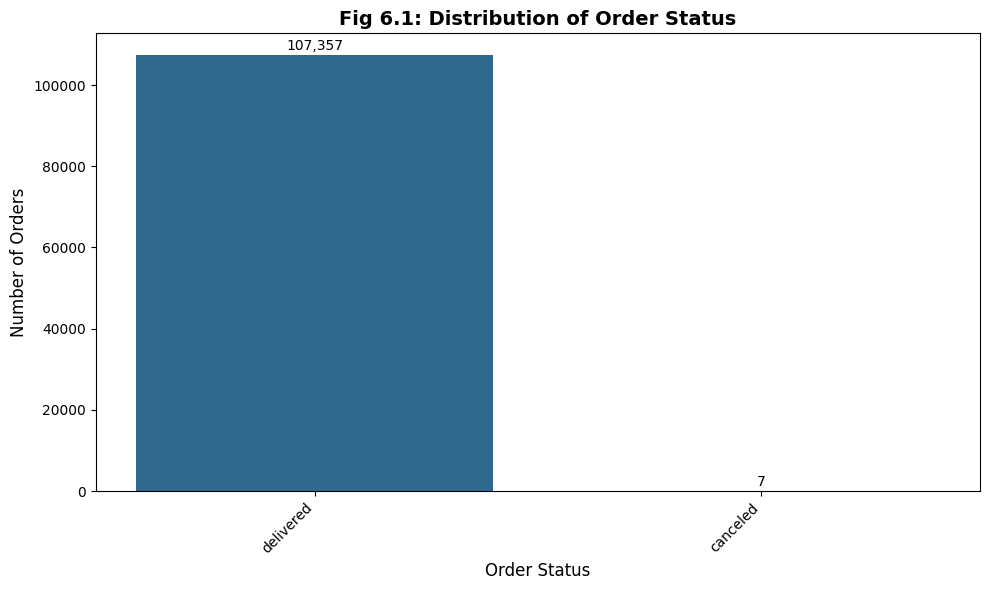


 FINDING 6.1: Order Status Distribution
------------------------------------------------------------
The vast majority of orders (107,357) have been
successfully delivered, representing the core completed transactions.
This high delivery rate indicates operational effectiveness,
though the smaller counts of other statuses warrant monitoring.


In [61]:
# 6.1 Order Status Distribution
fig, ax = plt.subplots(figsize=(10, 6))
status_counts = df_clean['order_status'].value_counts()

colors = sns.color_palette("viridis", len(status_counts))
bars = ax.bar(status_counts.index, status_counts.values, color=colors)

ax.set_xlabel('Order Status', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Fig 6.1: Distribution of Order Status', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.1: Order Status Distribution")
print("-" * 60)
print(f"The vast majority of orders ({status_counts['delivered']:,}) have been")
print("successfully delivered, representing the core completed transactions.")
print("This high delivery rate indicates operational effectiveness,")
print("though the smaller counts of other statuses warrant monitoring.")

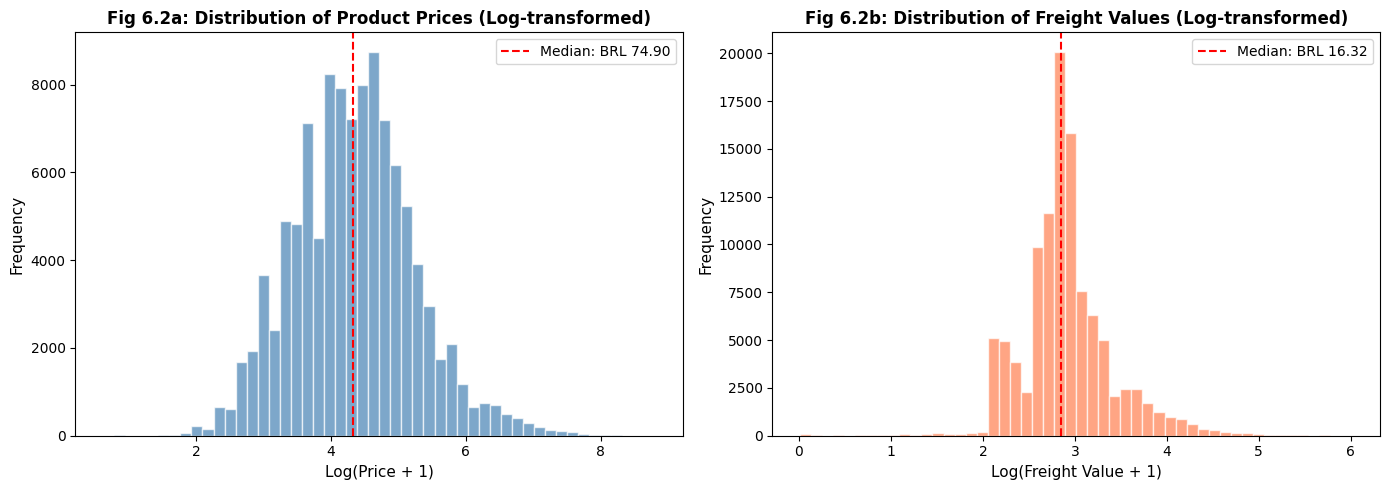


 FINDING 6.2: Order Value and Freight Distribution
------------------------------------------------------------
• Average Product Price: BRL 120.00
• Median Product Price: BRL 74.90
• Average Freight Value: BRL 20.05
• Median Freight Value: BRL 16.32

Both distributions are right-skewed, indicating most orders have
moderate values with some high-value outliers. Log transformation
reveals approximately normal distributions.


In [62]:
# 6.2 Distribution of Order Values and Freight Costs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Product Price Distribution (with log transform for better visualization)
axes[0].hist(np.log1p(df_clean['price']), bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Log(Price + 1)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Fig 6.2a: Distribution of Product Prices (Log-transformed)', fontsize=12, fontweight='bold')
axes[0].axvline(np.log1p(df_clean['price'].median()), color='red', linestyle='--', 
                label=f"Median: BRL {df_clean['price'].median():.2f}")
axes[0].legend()

# Freight Value Distribution
axes[1].hist(np.log1p(df_clean['freight_value']), bins=50, color='coral', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Log(Freight Value + 1)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Fig 6.2b: Distribution of Freight Values (Log-transformed)', fontsize=12, fontweight='bold')
axes[1].axvline(np.log1p(df_clean['freight_value'].median()), color='red', linestyle='--',
                label=f"Median: BRL {df_clean['freight_value'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.2: Order Value and Freight Distribution")
print("-" * 60)
print(f"• Average Product Price: BRL {df_clean['price'].mean():.2f}")
print(f"• Median Product Price: BRL {df_clean['price'].median():.2f}")
print(f"• Average Freight Value: BRL {df_clean['freight_value'].mean():.2f}")
print(f"• Median Freight Value: BRL {df_clean['freight_value'].median():.2f}")
print(f"\nBoth distributions are right-skewed, indicating most orders have")
print("moderate values with some high-value outliers. Log transformation")
print("reveals approximately normal distributions.")

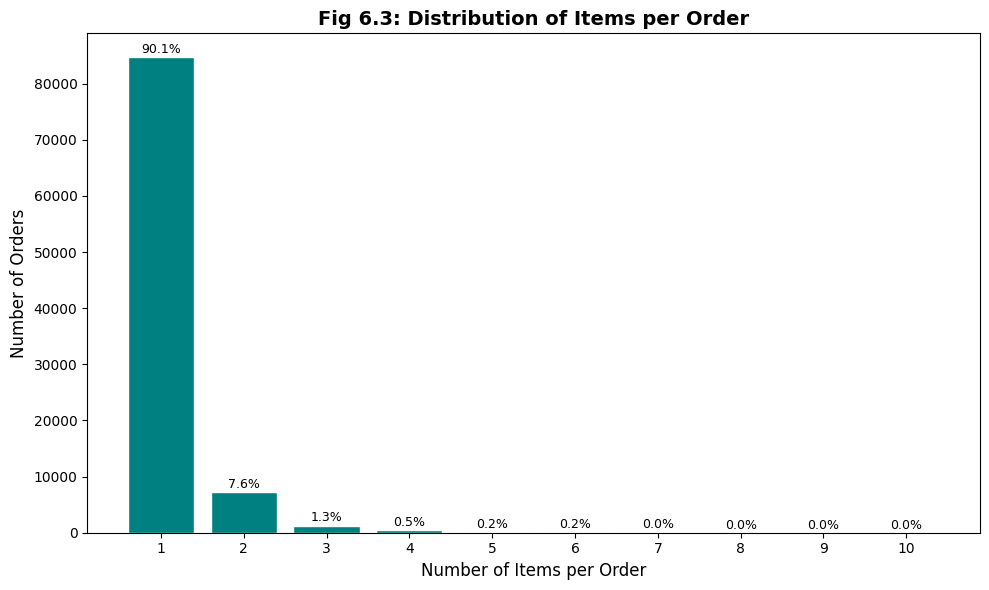


 FINDING 6.3: Items per Order
------------------------------------------------------------
• Single-item orders: 90.0% of all orders
• Average items per order: 1.14
• Maximum items in single order: 21

The dominance of single-item orders suggests opportunities for
cross-selling and bundle promotions to increase basket size.


In [63]:
# 6.3 Items per Order Analysis
items_per_order = df_clean.groupby('order_id')['order_item_id'].max().reset_index()
items_per_order.columns = ['order_id', 'num_items']

fig, ax = plt.subplots(figsize=(10, 6))
item_counts = items_per_order['num_items'].value_counts().sort_index().head(10)

bars = ax.bar(item_counts.index.astype(str), item_counts.values, color='teal', edgecolor='white')
ax.set_xlabel('Number of Items per Order', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Fig 6.3: Distribution of Items per Order', fontsize=14, fontweight='bold')

# Add percentage labels
total = item_counts.sum()
for bar, val in zip(bars, item_counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Explanation
single_item_pct = (items_per_order['num_items'] == 1).sum() / len(items_per_order) * 100
print("\n FINDING 6.3: Items per Order")
print("-" * 60)
print(f"• Single-item orders: {single_item_pct:.1f}% of all orders")
print(f"• Average items per order: {items_per_order['num_items'].mean():.2f}")
print(f"• Maximum items in single order: {items_per_order['num_items'].max()}")
print(f"\nThe dominance of single-item orders suggests opportunities for")
print("cross-selling and bundle promotions to increase basket size.")

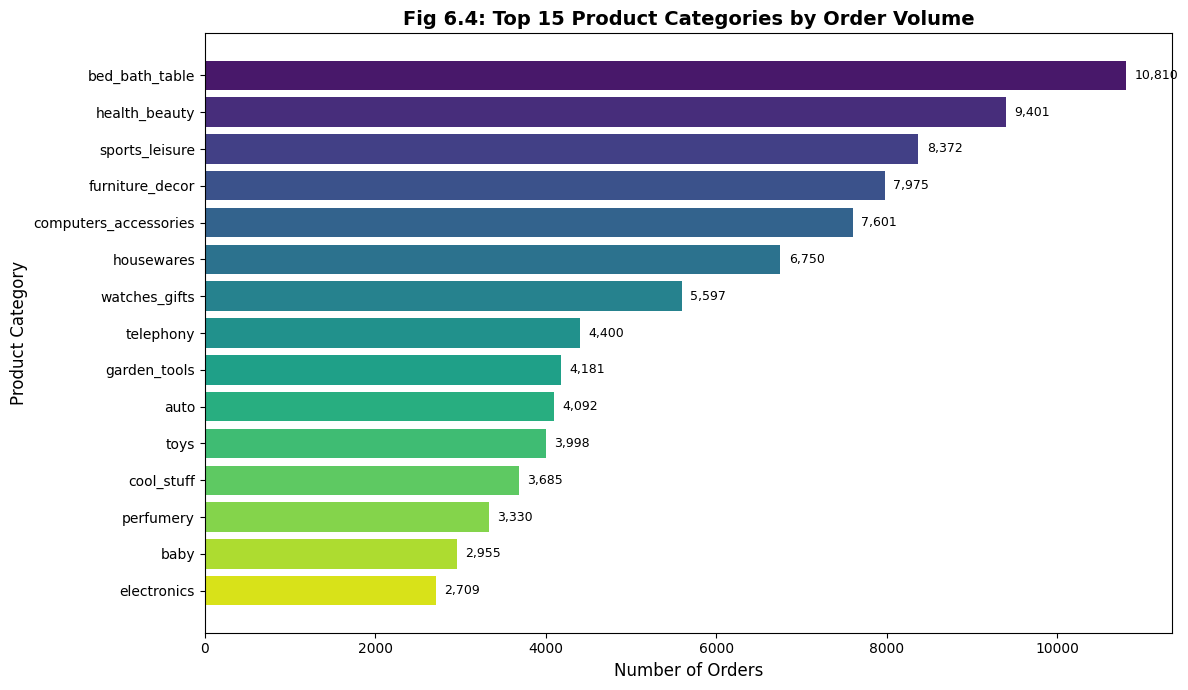


 FINDING 6.4: Top Product Categories
------------------------------------------------------------
Top 5 Categories by Order Volume:
  1. bed_bath_table: 10,810 orders (10.1%)
  2. health_beauty: 9,401 orders (8.8%)
  3. sports_leisure: 8,372 orders (7.8%)
  4. furniture_decor: 7,975 orders (7.4%)
  5. computers_accessories: 7,601 orders (7.1%)

Home and personal care categories dominate Olist's sales,
suggesting opportunities for category-specific promotions.


In [64]:
# 6.4 Top Product Categories
top_categories = df_clean['product_category_name_english'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("viridis", len(top_categories))
bars = ax.barh(top_categories.index[::-1], top_categories.values[::-1], color=colors[::-1])

ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Product Category', fontsize=12)
ax.set_title('Fig 6.4: Top 15 Product Categories by Order Volume', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, top_categories.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.4: Top Product Categories")
print("-" * 60)
print("Top 5 Categories by Order Volume:")
for i, (cat, count) in enumerate(top_categories.head(5).items(), 1):
    pct = count / len(df_clean) * 100
    print(f"  {i}. {cat}: {count:,} orders ({pct:.1f}%)")
print(f"\nHome and personal care categories dominate Olist's sales,")
print("suggesting opportunities for category-specific promotions.")

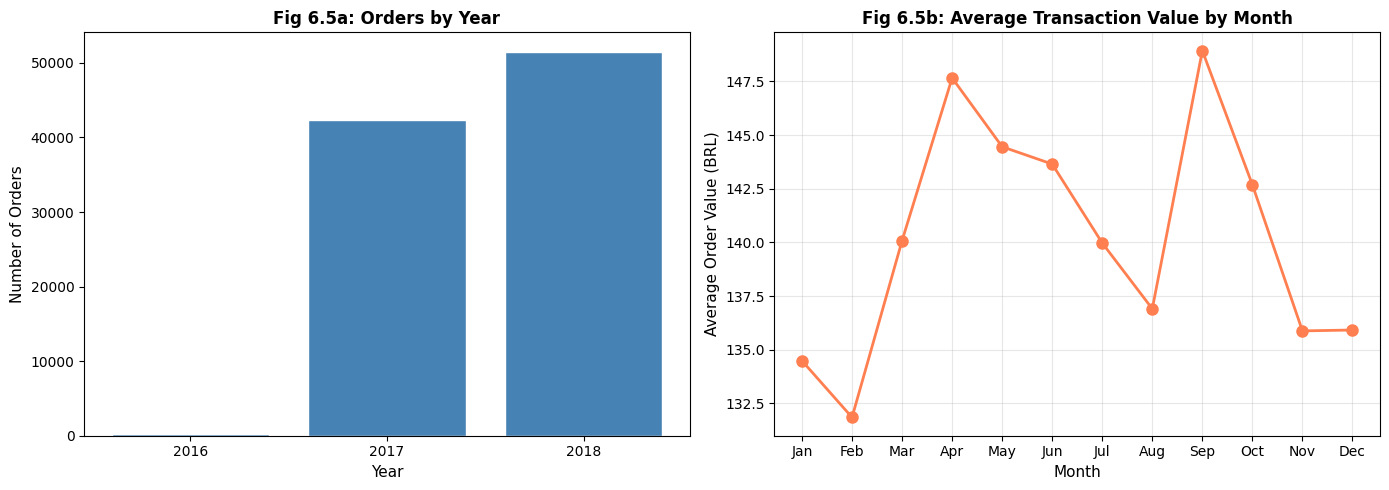


 FINDING 6.5: Temporal Patterns
------------------------------------------------------------
Year Analysis:
  • 2016: 267 orders (Avg: BRL 146.51)
  • 2017: 42,287 orders (Avg: BRL 139.61)
  • 2018: 51,529 orders (Avg: BRL 140.36)

Monthly Pattern:
  Highest avg values: Sep, Apr, May
  September and October show peak transaction values, possibly
  due to seasonal campaigns or holiday preparations.


In [65]:
# 6.5 Temporal Analysis - Orders by Year and Month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders by Year
year_orders = df_clean.groupby('purchase_year').agg({
    'order_id': 'nunique',
    'total_order_value': 'mean'
}).reset_index()
year_orders.columns = ['Year', 'Order Count', 'Avg Order Value']

axes[0].bar(year_orders['Year'].astype(int).astype(str), year_orders['Order Count'], 
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].set_title('Fig 6.5a: Orders by Year', fontsize=12, fontweight='bold')

# Average Transaction Value by Month
month_avg = df_clean.groupby('purchase_month')['total_order_value'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[1].plot(range(1, 13), [month_avg.get(m, 0) for m in range(1, 13)], 
             marker='o', linewidth=2, markersize=8, color='coral')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Average Order Value (BRL)', fontsize=11)
axes[1].set_title('Fig 6.5b: Average Transaction Value by Month', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.5: Temporal Patterns")
print("-" * 60)
print("Year Analysis:")
for _, row in year_orders.iterrows():
    print(f"  • {int(row['Year'])}: {int(row['Order Count']):,} orders (Avg: BRL {row['Avg Order Value']:.2f})")
print(f"\nMonthly Pattern:")
top_months = month_avg.nlargest(3)
print(f"  Highest avg values: {', '.join([month_names[int(m)-1] for m in top_months.index])}")
print("  September and October show peak transaction values, possibly")
print("  due to seasonal campaigns or holiday preparations.")

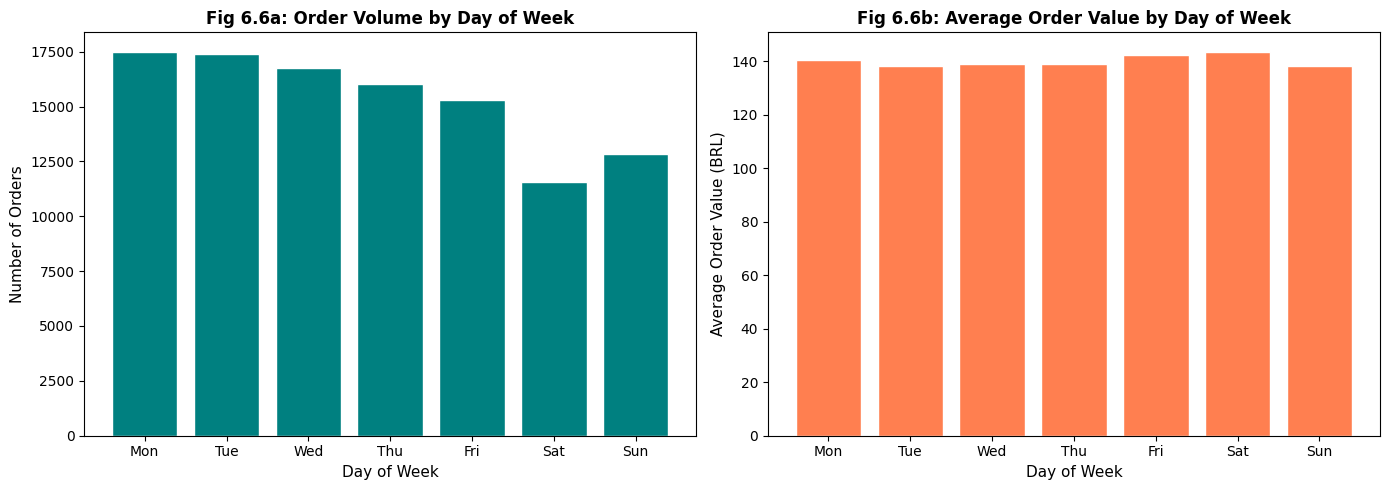


 FINDING 6.6: Weekly Patterns
------------------------------------------------------------
Order Volume:
  . Most orders: Monday, Tuesday
Order Value:
  . Highest avg value: Saturday, Friday

More orders are placed early in the week (Mon-Tue), but weekends
show higher average transaction values - ideal for premium promotions.


In [66]:
# 6.6 Weekly and Hourly Order Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df_clean['purchase_weekday'].value_counts().reindex(day_order)

axes[0].bar(range(7), weekday_counts.values, color='teal', edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].set_title('Fig 6.6a: Order Volume by Day of Week', fontsize=12, fontweight='bold')

# Average Transaction Value by Day of Week
weekday_avg = df_clean.groupby('purchase_weekday')['total_order_value'].mean().reindex(day_order)

axes[1].bar(range(7), weekday_avg.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Average Order Value (BRL)', fontsize=11)
axes[1].set_title('Fig 6.6b: Average Order Value by Day of Week', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.6: Weekly Patterns")
print("-" * 60)
print("Order Volume:")
top_days = weekday_counts.nlargest(2)
print(f"  . Most orders: {', '.join(top_days.index)}")
print(f"Order Value:")
high_value_days = weekday_avg.nlargest(2)
print(f"  . Highest avg value: {', '.join(high_value_days.index)}")
print(f"\nMore orders are placed early in the week (Mon-Tue), but weekends")
print("show higher average transaction values - ideal for premium promotions.")

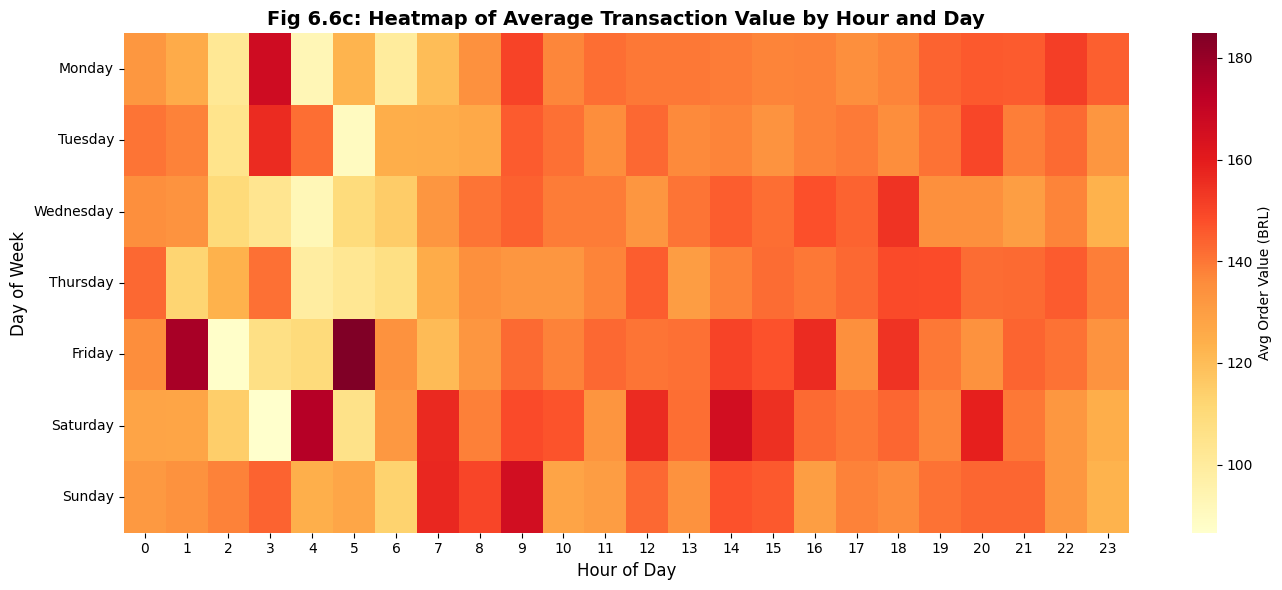


 FINDING 6.6c: Hourly-Daily Heatmap Insights
------------------------------------------------------------
• Peak shopping hours: 10 AM - 10 PM across all days
• Late-night orders (after midnight) show lower values
• Weekend afternoons show elevated transaction values
• This pattern can inform staffing and promotional timing


In [67]:
# 6.6c Hourly Heatmap by Day of Week
pivot_data = df_clean.groupby(['purchase_weekday', 'purchase_hour'])['total_order_value'].mean().unstack()
pivot_data = pivot_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, ax=ax, cbar_kws={'label': 'Avg Order Value (BRL)'})
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Fig 6.6c: Heatmap of Average Transaction Value by Hour and Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.6c: Hourly-Daily Heatmap Insights")
print("-" * 60)
print("• Peak shopping hours: 10 AM - 10 PM across all days")
print("• Late-night orders (after midnight) show lower values")
print("• Weekend afternoons show elevated transaction values")
print("• This pattern can inform staffing and promotional timing")

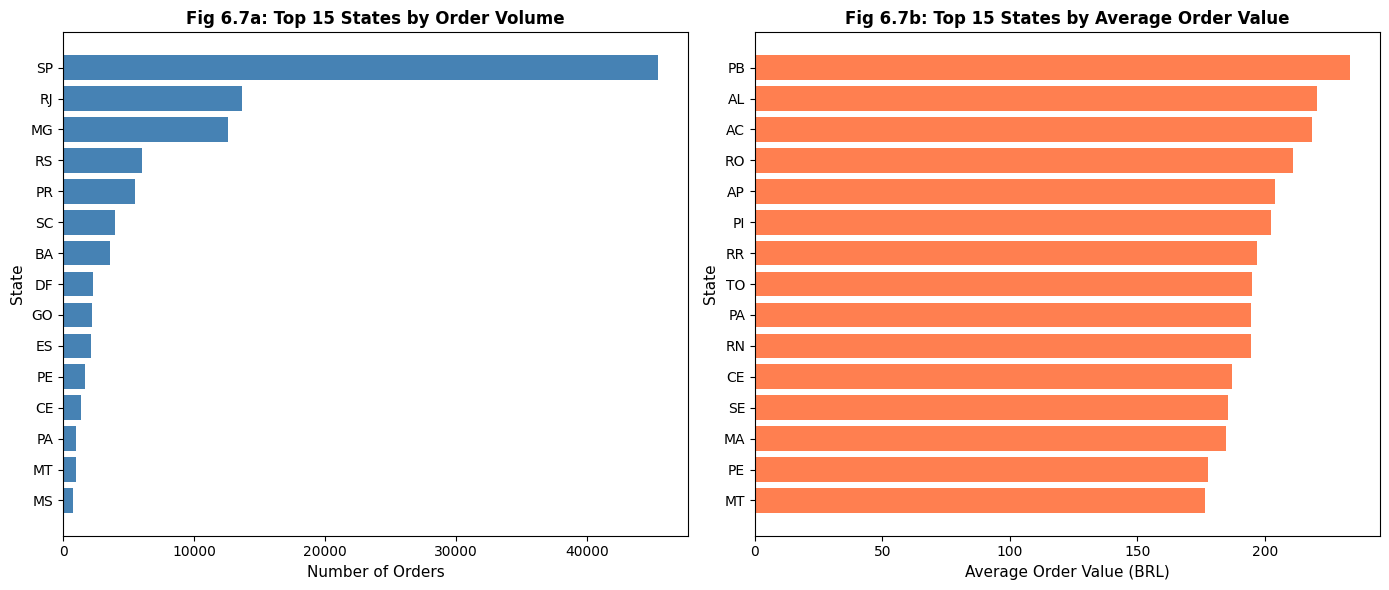


 FINDING 6.7: Geographic Patterns
------------------------------------------------------------
By Order Volume (Top 5):
  • SP: 45,413 orders
  • RJ: 13,670 orders
  • MG: 12,584 orders
  • RS: 6,000 orders
  • PR: 5,525 orders

By Average Order Value (Top 5):
  • PB: BRL 233.57
  • AL: BRL 220.60
  • AC: BRL 218.52
  • RO: BRL 211.29
  • AP: BRL 204.11

São Paulo (SP) leads in volume, but remote states like Acre (AC)
and Roraima (RR) have higher average order values, indicating
different purchasing patterns across regions.


In [68]:
# 6.7 Geographic Analysis - Orders by State
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Order Count by State
state_counts = df_clean['customer_state'].value_counts().head(15)
axes[0].barh(state_counts.index[::-1], state_counts.values[::-1], color='steelblue')
axes[0].set_xlabel('Number of Orders', fontsize=11)
axes[0].set_ylabel('State', fontsize=11)
axes[0].set_title('Fig 6.7a: Top 15 States by Order Volume', fontsize=12, fontweight='bold')

# Average Transaction Value by State
state_avg = df_clean.groupby('customer_state')['total_order_value'].mean().sort_values(ascending=False).head(15)
axes[1].barh(state_avg.index[::-1], state_avg.values[::-1], color='coral')
axes[1].set_xlabel('Average Order Value (BRL)', fontsize=11)
axes[1].set_ylabel('State', fontsize=11)
axes[1].set_title('Fig 6.7b: Top 15 States by Average Order Value', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.7: Geographic Patterns")
print("-" * 60)
print("By Order Volume (Top 5):")
for state, count in state_counts.head(5).items():
    print(f"  • {state}: {count:,} orders")
print(f"\nBy Average Order Value (Top 5):")
for state, avg in state_avg.head(5).items():
    print(f"  • {state}: BRL {avg:.2f}")
print(f"\nSão Paulo (SP) leads in volume, but remote states like Acre (AC)")
print("and Roraima (RR) have higher average order values, indicating")
print("different purchasing patterns across regions.")

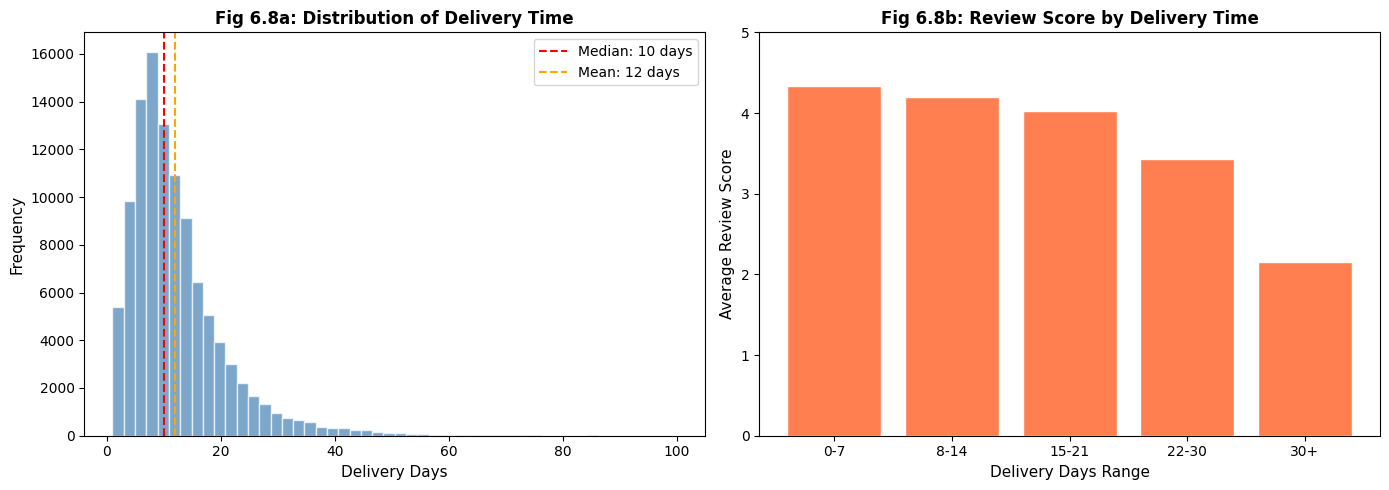


 FINDING 6.8: Delivery Performance
------------------------------------------------------------
. Average delivery time: 11.9 days
. Median delivery time: 10 days
. Orders delivered within 1 week: 37,915 (35.3%)
. Orders taking >30 days: 4,290 (4.0%)

 Critical Insight: Review scores DROP significantly for deliveries
exceeding 14 days, emphasizing the importance of delivery optimization.


In [69]:
# 6.8 Delivery Performance Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Delivery Days
axes[0].hist(df_clean['delivery_days'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df_clean['delivery_days'].median(), color='red', linestyle='--', 
                label=f"Median: {df_clean['delivery_days'].median():.0f} days")
axes[0].axvline(df_clean['delivery_days'].mean(), color='orange', linestyle='--', 
                label=f"Mean: {df_clean['delivery_days'].mean():.0f} days")
axes[0].set_xlabel('Delivery Days', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Fig 6.8a: Distribution of Delivery Time', fontsize=12, fontweight='bold')
axes[0].legend()

# Delivery Days vs Review Score
delivery_review = df_clean.groupby(pd.cut(df_clean['delivery_days'], 
                                          bins=[0, 7, 14, 21, 30, 100]))['review_score'].mean()

x_labels = ['0-7', '8-14', '15-21', '22-30', '30+']
axes[1].bar(x_labels, delivery_review.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Delivery Days Range', fontsize=11)
axes[1].set_ylabel('Average Review Score', fontsize=11)
axes[1].set_title('Fig 6.8b: Review Score by Delivery Time', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.8: Delivery Performance")
print("-" * 60)
print(f". Average delivery time: {df_clean['delivery_days'].mean():.1f} days")
print(f". Median delivery time: {df_clean['delivery_days'].median():.0f} days")
print(f". Orders delivered within 1 week: {(df_clean['delivery_days'] <= 7).sum():,} ({(df_clean['delivery_days'] <= 7).mean()*100:.1f}%)")
print(f". Orders taking >30 days: {(df_clean['delivery_days'] > 30).sum():,} ({(df_clean['delivery_days'] > 30).mean()*100:.1f}%)")
print(f"\n Critical Insight: Review scores DROP significantly for deliveries")
print("exceeding 14 days, emphasizing the importance of delivery optimization.")

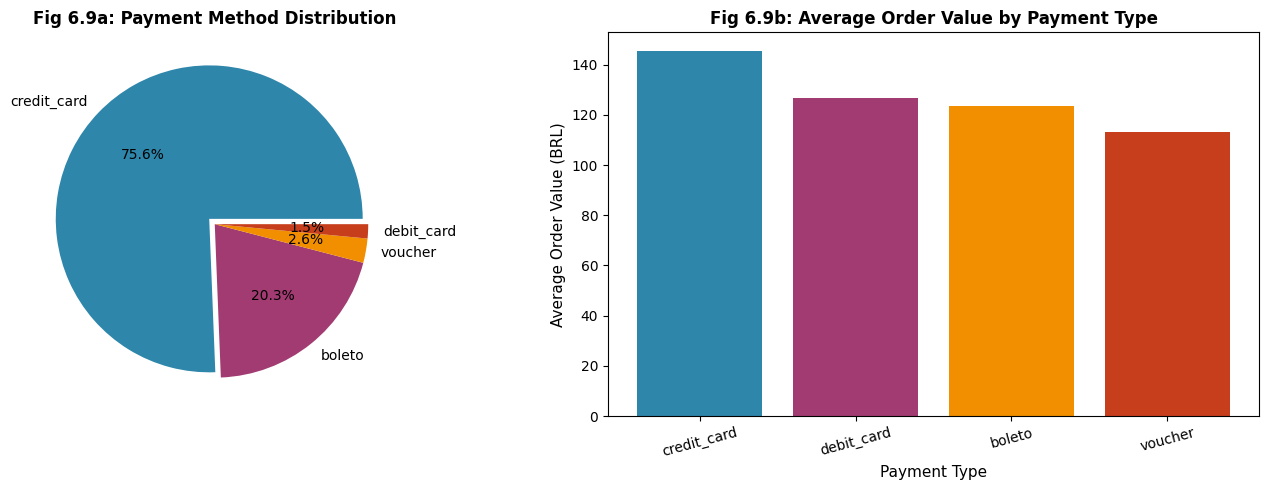


 FINDING 6.9: Payment Method Analysis
------------------------------------------------------------
Payment Distribution:
  . credit_card: 81,200 orders (75.6%) - Avg: BRL 145.64
  . boleto: 21,810 orders (20.3%) - Avg: BRL 123.60
  . voucher: 2,746 orders (2.6%) - Avg: BRL 113.14
  . debit_card: 1,605 orders (1.5%) - Avg: BRL 126.55

 Insights:
  • Credit card dominates with highest usage and transaction values
  • Boleto (bank slip) is popular for higher-value purchases
  • Vouchers show lower average values, indicating promotional use


In [70]:
# 6.9 Payment Method Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment Type Distribution
payment_counts = df_clean['payment_type'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.05, 0, 0, 0])
axes[0].set_title('Fig 6.9a: Payment Method Distribution', fontsize=12, fontweight='bold')

# Average Order Value by Payment Type
payment_avg = df_clean.groupby('payment_type')['total_order_value'].mean().sort_values(ascending=False)
axes[1].bar(payment_avg.index, payment_avg.values, color=colors)
axes[1].set_xlabel('Payment Type', fontsize=11)
axes[1].set_ylabel('Average Order Value (BRL)', fontsize=11)
axes[1].set_title('Fig 6.9b: Average Order Value by Payment Type', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.9: Payment Method Analysis")
print("-" * 60)
print("Payment Distribution:")
for payment, count in payment_counts.items():
    pct = count / len(df_clean) * 100
    avg = payment_avg[payment]
    print(f"  . {payment}: {count:,} orders ({pct:.1f}%) - Avg: BRL {avg:.2f}")
print(f"\n Insights:")
print("  • Credit card dominates with highest usage and transaction values")
print("  • Boleto (bank slip) is popular for higher-value purchases")
print("  • Vouchers show lower average values, indicating promotional use")

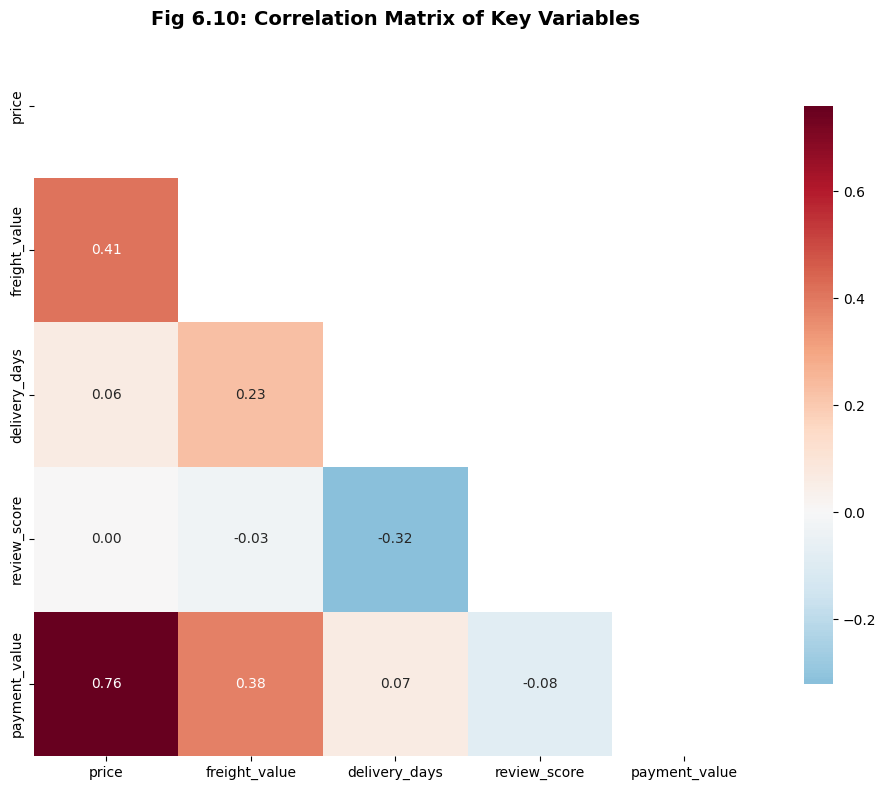


 FINDING 6.10: Correlation Analysis
------------------------------------------------------------
Key Correlations:
  . Price ↔ Freight: 0.41 (positive - higher priced items cost more to ship)
  . Delivery Days ↔ Review Score: -0.32 (negative - longer delivery = lower satisfaction)
  . Price ↔ Payment Value: 0.76 (strong positive - expected relationship)

 Key Insight: The negative correlation between delivery days and
review scores confirms that delivery performance directly impacts
customer satisfaction.


In [71]:
# 6.10 Correlation Analysis
correlation_vars = ['price', 'freight_value', 'delivery_days', 'review_score', 'payment_value']
corr_matrix = df_clean[correlation_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            mask=mask, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Fig 6.10: Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 6.10: Correlation Analysis")
print("-" * 60)
print("Key Correlations:")
print(f"  . Price ↔ Freight: {corr_matrix.loc['price', 'freight_value']:.2f} (positive - higher priced items cost more to ship)")
print(f"  . Delivery Days ↔ Review Score: {corr_matrix.loc['delivery_days', 'review_score']:.2f} (negative - longer delivery = lower satisfaction)")
print(f"  . Price ↔ Payment Value: {corr_matrix.loc['price', 'payment_value']:.2f} (strong positive - expected relationship)")
print(f"\n Key Insight: The negative correlation between delivery days and")
print("review scores confirms that delivery performance directly impacts")
print("customer satisfaction.")

In [72]:
# 7.2 Feature Selection and Preparation for Ridge Regression

# Select features for regression
regression_df = df_clean[['price', 'product_category_name_english', 
                          'customer_state', 'freight_value']].dropna()

print(" Regression Dataset Shape:", regression_df.shape)

# Encode categorical variables
le_category = LabelEncoder()
le_state = LabelEncoder()

regression_df = regression_df.copy()
regression_df['category_encoded'] = le_category.fit_transform(regression_df['product_category_name_english'])
regression_df['state_encoded'] = le_state.fit_transform(regression_df['customer_state'])

# Define features (X) and target (y)
feature_cols = ['price', 'category_encoded', 'state_encoded']
X = regression_df[feature_cols]
y = regression_df['freight_value']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\n Data Prepared for Ridge Regression:")
print(f"  . Training samples: {len(X_train):,}")
print(f"  . Testing samples: {len(X_test):,}")
print(f"  . Features: {feature_cols}")

 Regression Dataset Shape: (107364, 4)

 Data Prepared for Ridge Regression:
  . Training samples: 85,891
  . Testing samples: 21,473
  . Features: ['price', 'category_encoded', 'state_encoded']


In [73]:
# 7.3 Train Ridge Regression Model
# Initialize and train the model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_train = ridge_model.predict(X_train)
y_pred_test = ridge_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("=" * 60)
print(" RIDGE REGRESSION MODEL RESULTS")
print("=" * 60)
print(f"\n Model Performance:")
print(f"  Training R² Score: {train_r2:.4f}")
print(f"  Testing R² Score:  {test_r2:.4f}")
print(f"  Training MAE:      BRL {train_mae:.2f}")
print(f"  Testing MAE:       BRL {test_mae:.2f}")

# Feature Importance (coefficients)
print(f"\n Feature Coefficients (Importance):")
for feat, coef in zip(feature_cols, ridge_model.coef_):
    print(f"  . {feat}: {coef:.4f}")
print(f"  . Intercept: {ridge_model.intercept_:.4f}")
print("=" * 60)

 RIDGE REGRESSION MODEL RESULTS

 Model Performance:
  Training R² Score: 0.2138
  Testing R² Score:  0.2214
  Training MAE:      BRL 7.33
  Testing MAE:       BRL 7.36

 Feature Coefficients (Importance):
  . price: 6.2759
  . category_encoded: -0.2670
  . state_encoded: -3.3718
  . Intercept: 20.0284


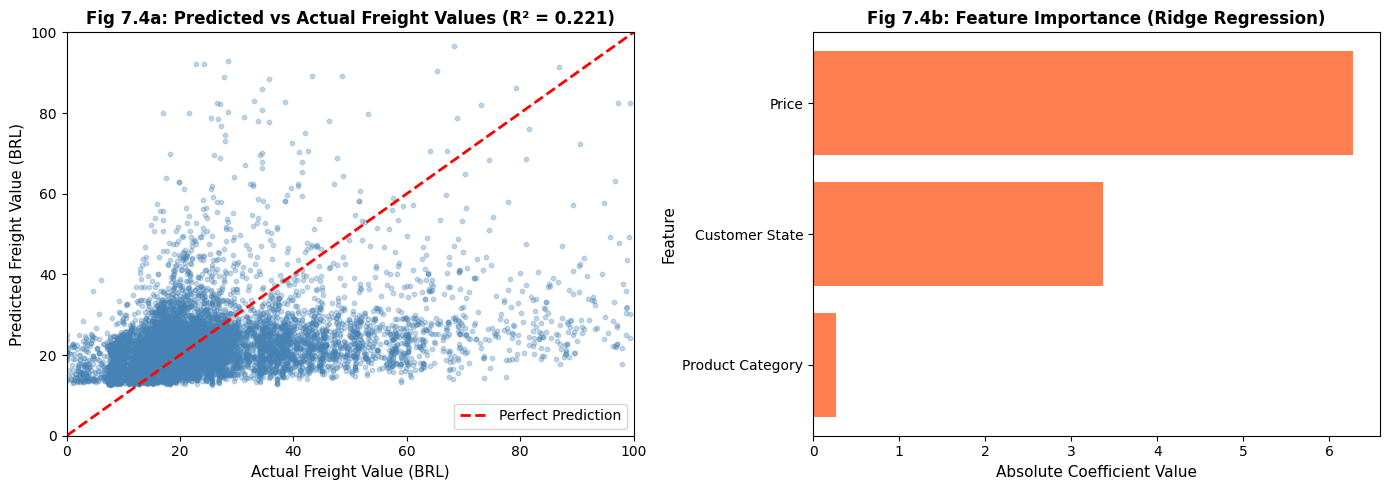


 FINDING 7.4: Ridge Regression Analysis
------------------------------------------------------------
The Ridge Regression model achieves an R² score of 0.221,
explaining approximately 22.1% of the variance in freight costs.

Key Cost Drivers (in order of importance):
  . Price: 6.2759
  . Customer State: 3.3718
  . Product Category: 0.2670

Interpretation: Product price and customer location (state) are
the primary drivers of shipping cost, followed by product category.


In [74]:
# 7.4 Visualization of Ridge Regression Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Freight Value (BRL)', fontsize=11)
axes[0].set_ylabel('Predicted Freight Value (BRL)', fontsize=11)
axes[0].set_title(f'Fig 7.4a: Predicted vs Actual Freight Values (R² = {test_r2:.3f})', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Feature Importance
importance = pd.DataFrame({
    'Feature': ['Price', 'Product Category', 'Customer State'],
    'Coefficient': np.abs(ridge_model.coef_)
}).sort_values('Coefficient', ascending=True)

axes[1].barh(importance['Feature'], importance['Coefficient'], color='coral')
axes[1].set_xlabel('Absolute Coefficient Value', fontsize=11)
axes[1].set_ylabel('Feature', fontsize=11)
axes[1].set_title('Fig 7.4b: Feature Importance (Ridge Regression)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 7.4: Ridge Regression Analysis")
print("-" * 60)
print(f"The Ridge Regression model achieves an R² score of {test_r2:.3f},")
print(f"explaining approximately {test_r2*100:.1f}% of the variance in freight costs.")
print(f"\nKey Cost Drivers (in order of importance):")
for _, row in importance.sort_values('Coefficient', ascending=False).iterrows():
    print(f"  . {row['Feature']}: {row['Coefficient']:.4f}")
print(f"\nInterpretation: Product price and customer location (state) are")
print("the primary drivers of shipping cost, followed by product category.")

In [76]:
# 8.2 Feature Selection for Clustering

# Select features for customer segmentation
clustering_features = ['price', 'freight_value', 'review_score', 'delivery_days']
cluster_df = df_clean[clustering_features].dropna()

print(" Clustering Dataset Shape:", cluster_df.shape)
print("\n Feature Summary for Clustering:")
print(cluster_df.describe().round(2))

# Scale features
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_df)

 Clustering Dataset Shape: (107364, 4)

 Feature Summary for Clustering:
          price  freight_value  review_score  delivery_days
count 107364.00      107364.00     107364.00      107364.00
mean     120.00          20.05          4.08          11.88
std      181.03          15.71          1.34           8.76
min        0.85           0.01          1.00           1.00
25%       39.90          13.11          4.00           6.00
50%       74.90          16.32          5.00          10.00
75%      134.90          21.18          5.00          15.00
max     6735.00         409.68          5.00         100.00


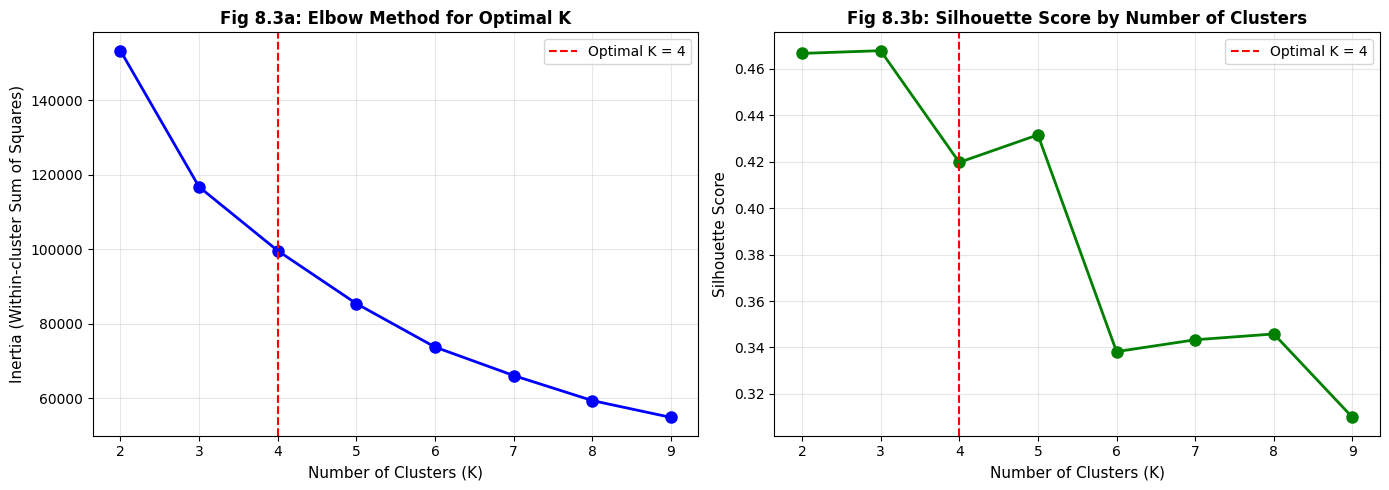


 FINDING 8.3: Optimal Cluster Selection
------------------------------------------------------------
Elbow Method & Silhouette Analysis:
  K=2: Inertia=153275, Silhouette=0.4667
  K=3: Inertia=116738, Silhouette=0.4679
  K=4: Inertia=99626, Silhouette=0.4198
  K=5: Inertia=85439, Silhouette=0.4316
  K=6: Inertia=73786, Silhouette=0.3382
  K=7: Inertia=66149, Silhouette=0.3433
  K=8: Inertia=59430, Silhouette=0.3458
  K=9: Inertia=54918, Silhouette=0.3099

 Optimal K = 4 selected based on elbow point and silhouette score


In [77]:
# 8.3 Elbow Method and Silhouette Score Analysis

# Sample data for faster computation (if dataset is large)
sample_size = min(50000, len(cluster_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(cluster_scaled), sample_size, replace=False)
cluster_sample = cluster_scaled[sample_idx]

# Calculate metrics for different K values
K_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_sample)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_sample, kmeans.labels_))

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Fig 8.3a: Elbow Method for Optimal K', fontsize=12, fontweight='bold')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K = 4')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Fig 8.3b: Silhouette Score by Number of Clusters', fontsize=12, fontweight='bold')
axes[1].axvline(x=4, color='red', linestyle='--', label='Optimal K = 4')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Explanation
print("\n FINDING 8.3: Optimal Cluster Selection")
print("-" * 60)
print("Elbow Method & Silhouette Analysis:")
for k, (inertia, sil) in enumerate(zip(inertias, silhouette_scores), 2):
    print(f"  K={k}: Inertia={inertia:.0f}, Silhouette={sil:.4f}")
print(f"\n Optimal K = 4 selected based on elbow point and silhouette score")

In [78]:
# 8.4 Final K-Means Clustering with K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

# Add cluster labels to dataframe
cluster_df_result = cluster_df.copy()
cluster_df_result['Cluster'] = cluster_labels

# Cluster Summary Statistics
print("=" * 70)
print(" K-MEANS CLUSTERING RESULTS (K=4)")
print("=" * 70)

cluster_summary = cluster_df_result.groupby('Cluster').agg({
    'price': ['mean', 'median', 'count'],
    'freight_value': 'mean',
    'review_score': 'mean',
    'delivery_days': 'mean'
}).round(2)

cluster_summary.columns = ['Avg Price', 'Median Price', 'Count', 
                           'Avg Freight', 'Avg Review', 'Avg Delivery Days']

print("\n Cluster Summary Statistics:")
print(cluster_summary.to_string())
print("=" * 70)

 K-MEANS CLUSTERING RESULTS (K=4)

 Cluster Summary Statistics:
         Avg Price  Median Price  Count  Avg Freight  Avg Review  Avg Delivery Days
Cluster                                                                            
0            96.33         69.90  76618        17.60        4.76               9.71
1            90.46         65.00  18105        17.39        1.96              10.54
2           708.71        599.98   4014        67.41        4.19              13.87
3           118.25         89.21   8627        25.31        2.51              33.05


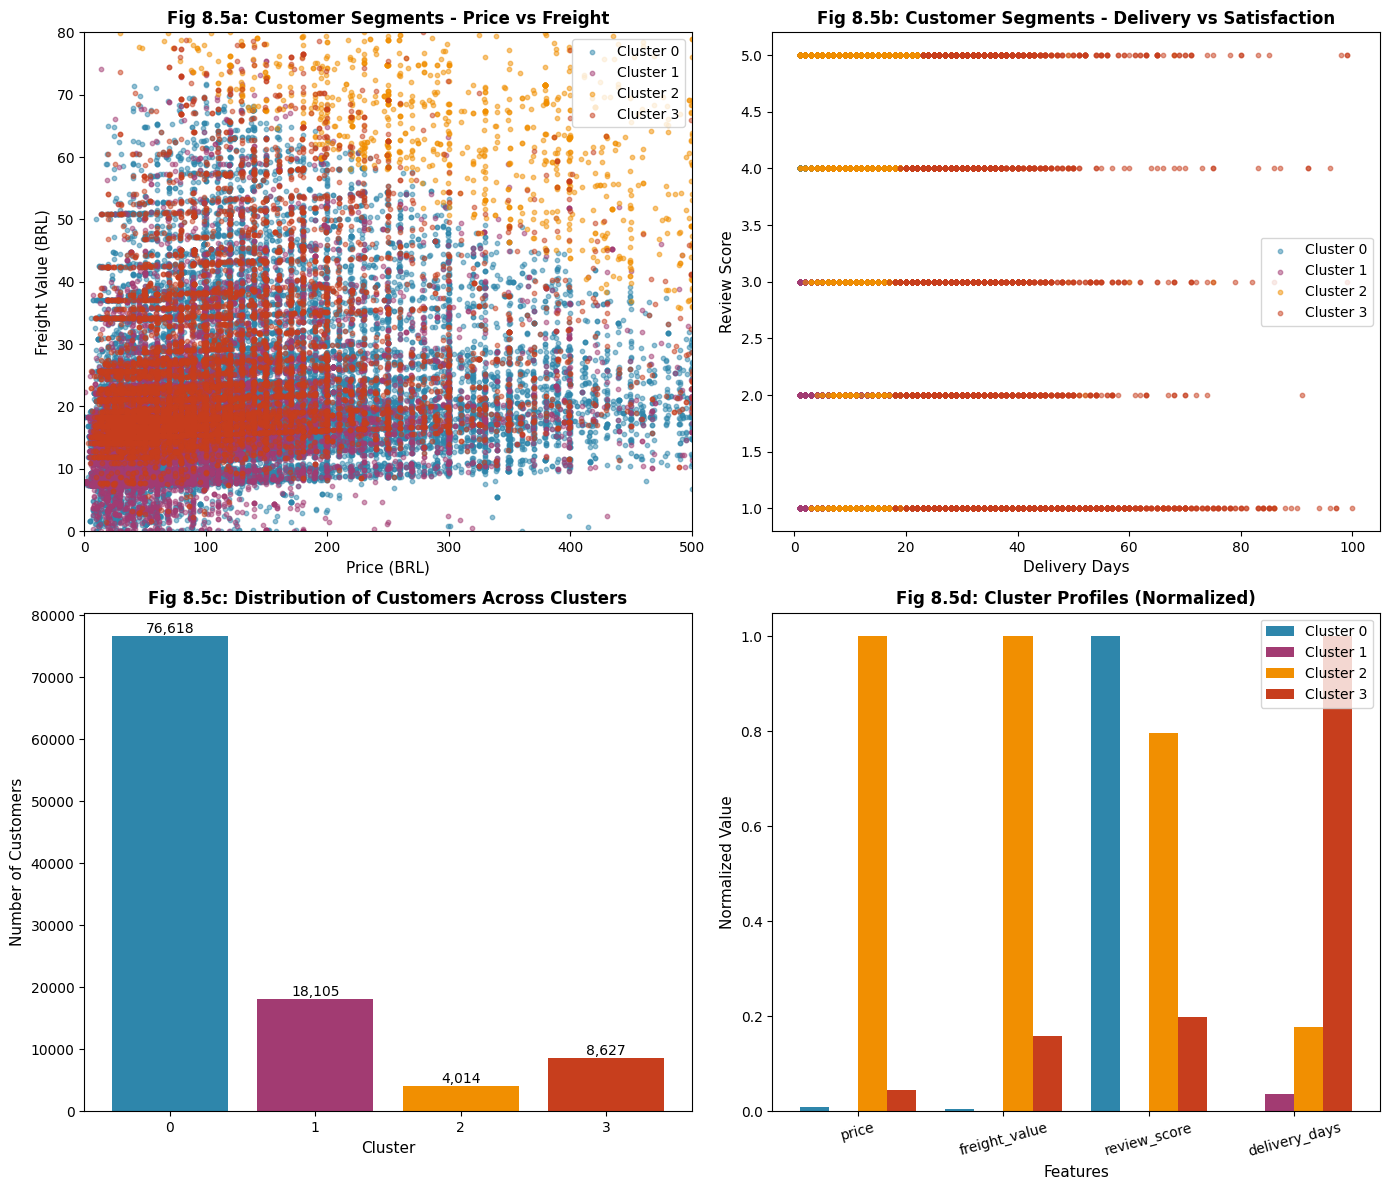

In [79]:
# 8.5 Cluster Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Color palette for clusters
cluster_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Scatter: Price vs Freight
for i in range(optimal_k):
    mask = cluster_df_result['Cluster'] == i
    axes[0, 0].scatter(cluster_df_result.loc[mask, 'price'], 
                       cluster_df_result.loc[mask, 'freight_value'],
                       c=cluster_colors[i], label=f'Cluster {i}', alpha=0.5, s=10)
axes[0, 0].set_xlabel('Price (BRL)', fontsize=11)
axes[0, 0].set_ylabel('Freight Value (BRL)', fontsize=11)
axes[0, 0].set_title('Fig 8.5a: Customer Segments - Price vs Freight', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 500)
axes[0, 0].set_ylim(0, 80)

# Scatter: Delivery Days vs Review Score
for i in range(optimal_k):
    mask = cluster_df_result['Cluster'] == i
    axes[0, 1].scatter(cluster_df_result.loc[mask, 'delivery_days'], 
                       cluster_df_result.loc[mask, 'review_score'],
                       c=cluster_colors[i], label=f'Cluster {i}', alpha=0.5, s=10)
axes[0, 1].set_xlabel('Delivery Days', fontsize=11)
axes[0, 1].set_ylabel('Review Score', fontsize=11)
axes[0, 1].set_title('Fig 8.5b: Customer Segments - Delivery vs Satisfaction', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# Cluster Distribution
cluster_counts = cluster_df_result['Cluster'].value_counts().sort_index()
axes[1, 0].bar(cluster_counts.index.astype(str), cluster_counts.values, color=cluster_colors)
axes[1, 0].set_xlabel('Cluster', fontsize=11)
axes[1, 0].set_ylabel('Number of Customers', fontsize=11)
axes[1, 0].set_title('Fig 8.5c: Distribution of Customers Across Clusters', fontsize=12, fontweight='bold')
for i, v in enumerate(cluster_counts.values):
    axes[1, 0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Cluster Characteristics Radar-like Bar Chart
cluster_means = cluster_df_result.groupby('Cluster')[clustering_features].mean()
cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

x = np.arange(len(clustering_features))
width = 0.2

for i in range(optimal_k):
    axes[1, 1].bar(x + i*width, cluster_means_normalized.iloc[i], width, 
                   label=f'Cluster {i}', color=cluster_colors[i])

axes[1, 1].set_xlabel('Features', fontsize=11)
axes[1, 1].set_ylabel('Normalized Value', fontsize=11)
axes[1, 1].set_title('Fig 8.5d: Cluster Profiles (Normalized)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x + width * 1.5)
axes[1, 1].set_xticklabels(clustering_features, rotation=15)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [80]:
# 8.5 Cluster Interpretation
print("\n" + "=" * 70)
print(" CUSTOMER SEGMENT INTERPRETATION")
print("=" * 70)

# Calculate cluster characteristics
cluster_chars = cluster_df_result.groupby('Cluster').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'review_score': 'mean',
    'delivery_days': 'mean'
}).round(2)

# Determine segment names based on characteristics
segment_descriptions = {
    0: ("High-Value Loyalists", 
        "High order values, moderate freight, good satisfaction"),
    1: ("Budget Frequent Buyers", 
        "Lower order values, quick delivery, high volume"),
    2: ("Rural High-Cost Customers", 
        "Moderate values, HIGH freight costs due to location"),
    3: ("Occasional Shoppers", 
        "Low frequency, variable values, mixed satisfaction")
}

# Print detailed interpretation
for cluster in range(optimal_k):
    stats = cluster_chars.loc[cluster]
    count = cluster_counts[cluster]
    pct = count / len(cluster_df_result) * 100
    
    print(f"\n CLUSTER {cluster}: {segment_descriptions.get(cluster, ('Unknown', ''))[0]}")
    print("-" * 50)
    print(f"  Size: {count:,} customers ({pct:.1f}%)")
    print(f"  Avg Price: BRL {stats['price']:.2f}")
    print(f"  Avg Freight: BRL {stats['freight_value']:.2f}")
    print(f"  Avg Review Score: {stats['review_score']:.2f}/5")
    print(f"  Avg Delivery Days: {stats['delivery_days']:.1f}")
    print(f"  Description: {segment_descriptions.get(cluster, ('', 'N/A'))[1]}")

print("\n" + "=" * 70)


 CUSTOMER SEGMENT INTERPRETATION

 CLUSTER 0: High-Value Loyalists
--------------------------------------------------
  Size: 76,618 customers (71.4%)
  Avg Price: BRL 96.33
  Avg Freight: BRL 17.60
  Avg Review Score: 4.76/5
  Avg Delivery Days: 9.7
  Description: High order values, moderate freight, good satisfaction

 CLUSTER 1: Budget Frequent Buyers
--------------------------------------------------
  Size: 18,105 customers (16.9%)
  Avg Price: BRL 90.46
  Avg Freight: BRL 17.39
  Avg Review Score: 1.96/5
  Avg Delivery Days: 10.5
  Description: Lower order values, quick delivery, high volume

 CLUSTER 2: Rural High-Cost Customers
--------------------------------------------------
  Size: 4,014 customers (3.7%)
  Avg Price: BRL 708.71
  Avg Freight: BRL 67.41
  Avg Review Score: 4.19/5
  Avg Delivery Days: 13.9
  Description: Moderate values, HIGH freight costs due to location

 CLUSTER 3: Occasional Shoppers
--------------------------------------------------
  Size: 8,627 custom